<a href="https://colab.research.google.com/github/visheshgupta19/Explainable-Deep-Learning/blob/main/Explainable_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 32.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=1c5c82e6ddf36709a36c2bec3b55b063bbab63886b719b3063cbf807057f2bff
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [2]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import os
from google.colab import drive

# GradCAM imports
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, ScoreCAM, SmoothGradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [3]:
model = models.resnet50(pretrained=True)
model.eval()

preprocess = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 88.4MB/s]


In [4]:
target_layer = model.layer4[-1]

cam_methods = {
    "GradCAM": GradCAM(model=model, target_layers=[target_layer]),
    "GradCAM++": GradCAMPlusPlus(model=model, target_layers=[target_layer]),
    "ScoreCAM": ScoreCAM(model=model, target_layers=[target_layer]),
    "SmoothGrad": SmoothGradCAM(model=model, target_layers=[target_layer]
}

In [ ]:
# Install gdown if not already installed
!pip install gdown

# Download the shared folder from Google Drive
!gdown --folder https://drive.google.com/drive/folders/1sBGrIXyviGxU8ZmHPdayTxT7047Cht1c?usp=share_link -O ./dataset-resized

# Verify download
import os
dataset_folder = './dataset-resized'
print("Classes found:", os.listdir(dataset_folder))


In [12]:
# drive.mount('/content/drive')
# dataset_folder = '/content/drive/MyDrive/dataset-resized'
# print(os.listdir(dataset_folder))

['trash', 'glass', 'paper', 'metal', 'cardboard', 'plastic']


In [13]:
class_folders = [f for f in os.listdir(dataset_folder) if os.path.isdir(os.path.join(dataset_folder, f))]

# Pick one image per class
sample_images = {}
for cls in class_folders:
    folder_path = os.path.join(dataset_folder, cls)
    images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    if images:
        sample_images[cls] = os.path.join(folder_path, images[0])  # pick first image

In [14]:
sample_images

{'trash': '/content/drive/MyDrive/dataset-resized/trash/trash1.jpg',
 'glass': '/content/drive/MyDrive/dataset-resized/glass/glass1.jpg',
 'paper': '/content/drive/MyDrive/dataset-resized/paper/paper1.jpg',
 'metal': '/content/drive/MyDrive/dataset-resized/metal/metal1.jpg',
 'cardboard': '/content/drive/MyDrive/dataset-resized/cardboard/cardboard1.jpg',
 'plastic': '/content/drive/MyDrive/dataset-resized/plastic/plastic1.jpg'}

In [15]:
def load_image_local(path):
    try:
        img = Image.open(path).convert("RGB")
        return img
    except:
        print(f"Error loading image: {path}")
        return None

def cam_overlap(cam1, cam2):
    cam1_norm = cam1 / cam1.max()
    cam2_norm = cam2 / cam2.max()
    return np.mean(np.minimum(cam1_norm, cam2_norm))

def apply_cams(img_pil, label, true_class_index=None):
    input_tensor = preprocess(img_pil).unsqueeze(0)

    # Model prediction
    outputs = model(input_tensor)
    probs = F.softmax(outputs, dim=1)
    pred_class = outputs.argmax(dim=1).item()
    pred_prob = probs[0, pred_class].item()

    rgb_img = np.array(img_pil.resize((224,224))) / 255.0

    fig, axes = plt.subplots(1, len(cam_methods)+1, figsize=(18,5))
    axes[0].imshow(img_pil)
    axes[0].set_title(f"Original: {label}\nPredicted: {pred_class} ({pred_prob:.2f})")
    axes[0].axis("off")

    cam_results = {}
    for i, (name, cam) in enumerate(cam_methods.items(), 1):
        if true_class_index is not None:
            target = [ClassifierOutputTarget(true_class_index)]
        else:
            target = None

        grayscale_cam = cam(input_tensor=input_tensor, targets=target)[0, :]
        cam_results[name] = grayscale_cam

        salient_area = (grayscale_cam > 0.5).sum() / grayscale_cam.size
        print(f"{name} salient fraction: {salient_area:.2f}")

        cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
        axes[i].imshow(cam_image)
        axes[i].set_title(name)
        axes[i].axis("off")

        save_path = f"cam_results/{label}_{name}.png"
        cv2.imwrite(save_path, cv2.cvtColor(cam_image, cv2.COLOR_RGB2BGR))

    plt.show()

    overlap_gc_gcpp = cam_overlap(cam_results["GradCAM"], cam_results["GradCAM++"])
    print(f"GradCAM vs GradCAM++ overlap: {overlap_gc_gcpp:.2f}\n")

GradCAM salient fraction: 0.31
GradCAM++ salient fraction: 0.34


100%|██████████| 128/128 [07:36<00:00,  3.56s/it]


ScoreCAM salient fraction: 0.34


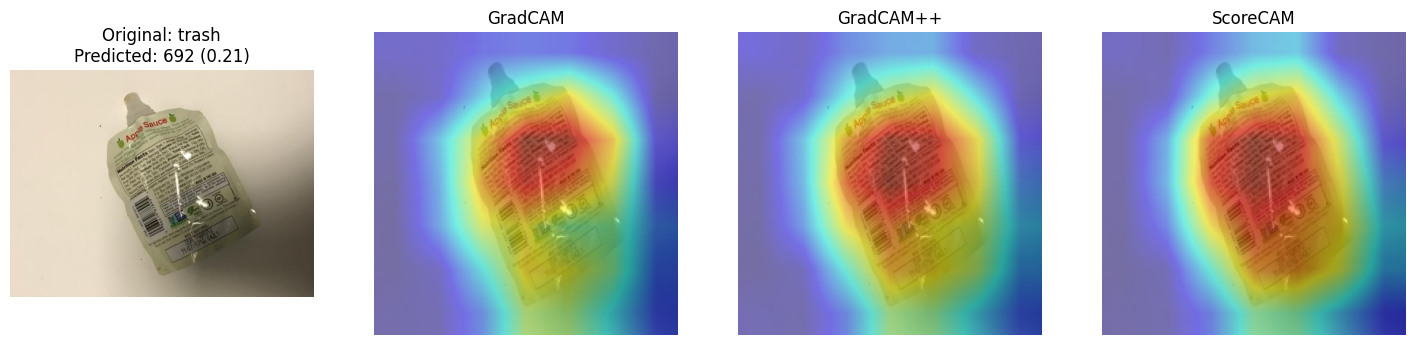

GradCAM vs GradCAM++ overlap: 0.34

GradCAM salient fraction: 0.31
GradCAM++ salient fraction: 0.34


100%|██████████| 128/128 [07:13<00:00,  3.39s/it]


ScoreCAM salient fraction: 0.26


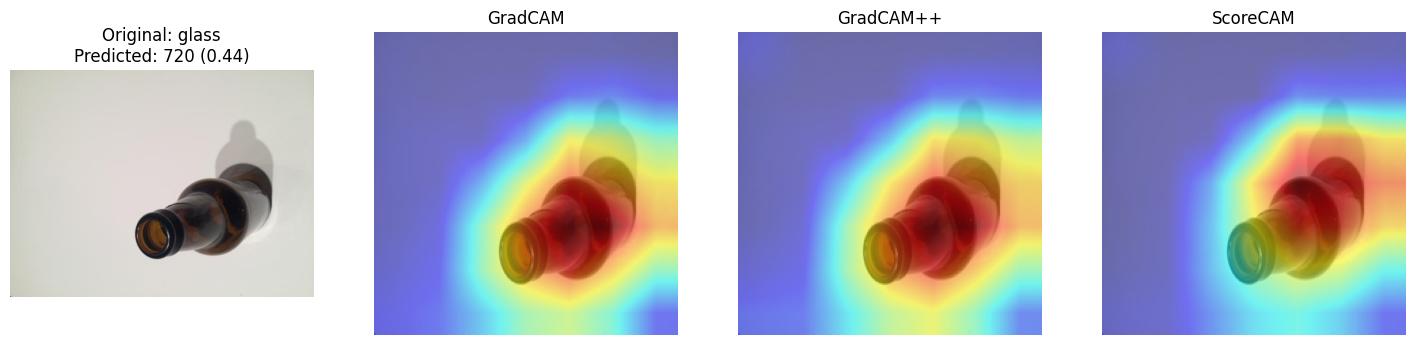

GradCAM vs GradCAM++ overlap: 0.31

GradCAM salient fraction: 0.27
GradCAM++ salient fraction: 0.29


100%|██████████| 128/128 [06:31<00:00,  3.06s/it]


ScoreCAM salient fraction: 0.24


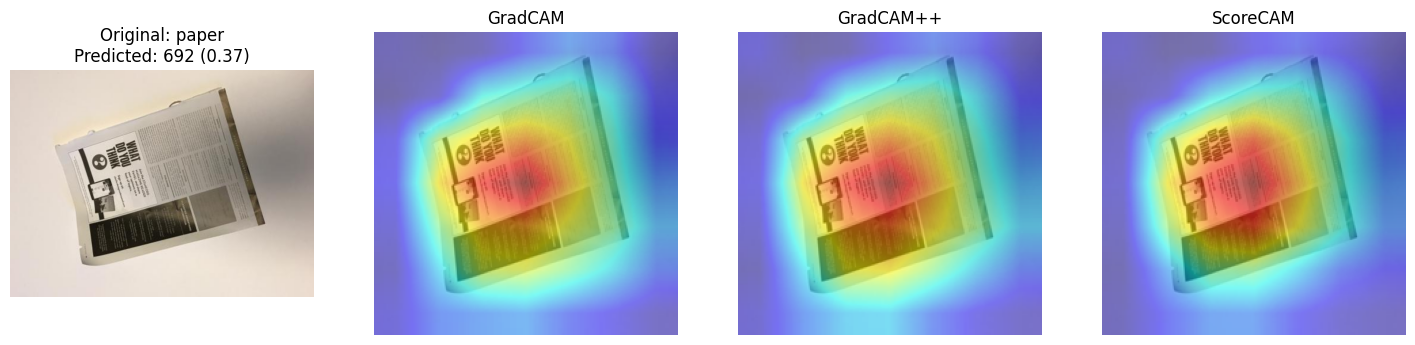

GradCAM vs GradCAM++ overlap: 0.34

GradCAM salient fraction: 0.30
GradCAM++ salient fraction: 0.34


100%|██████████| 128/128 [07:10<00:00,  3.37s/it]


ScoreCAM salient fraction: 0.28


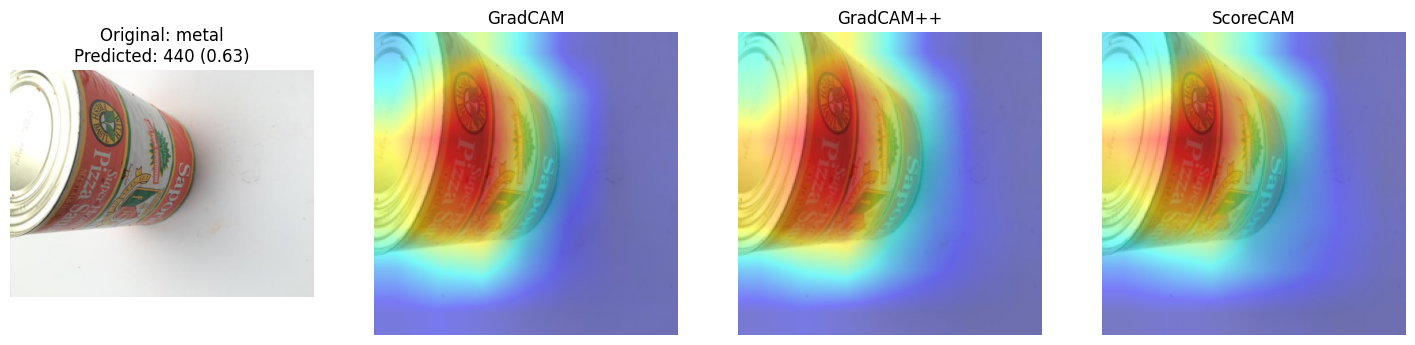

GradCAM vs GradCAM++ overlap: 0.31

GradCAM salient fraction: 0.28
GradCAM++ salient fraction: 0.33


100%|██████████| 128/128 [06:17<00:00,  2.95s/it]


ScoreCAM salient fraction: 0.26


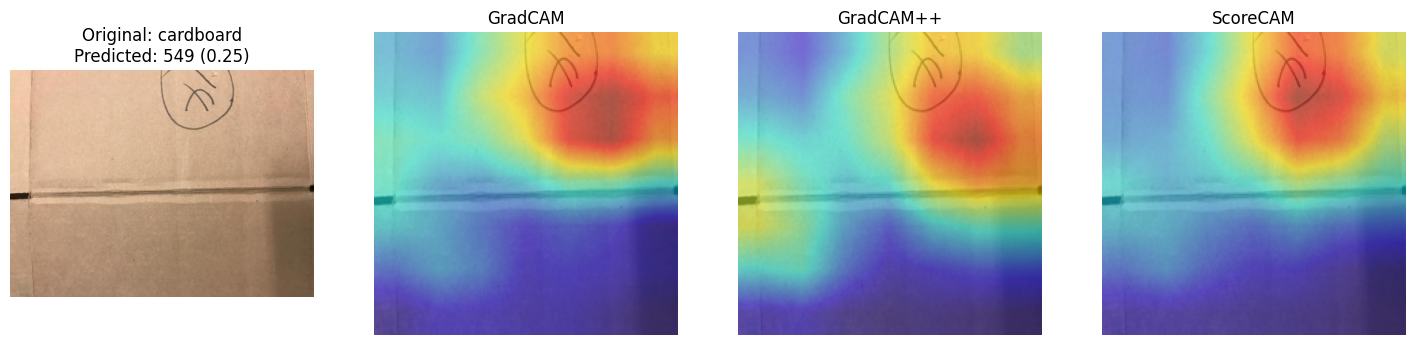

GradCAM vs GradCAM++ overlap: 0.34

GradCAM salient fraction: 0.21
GradCAM++ salient fraction: 0.24


100%|██████████| 128/128 [07:30<00:00,  3.52s/it]


ScoreCAM salient fraction: 0.32


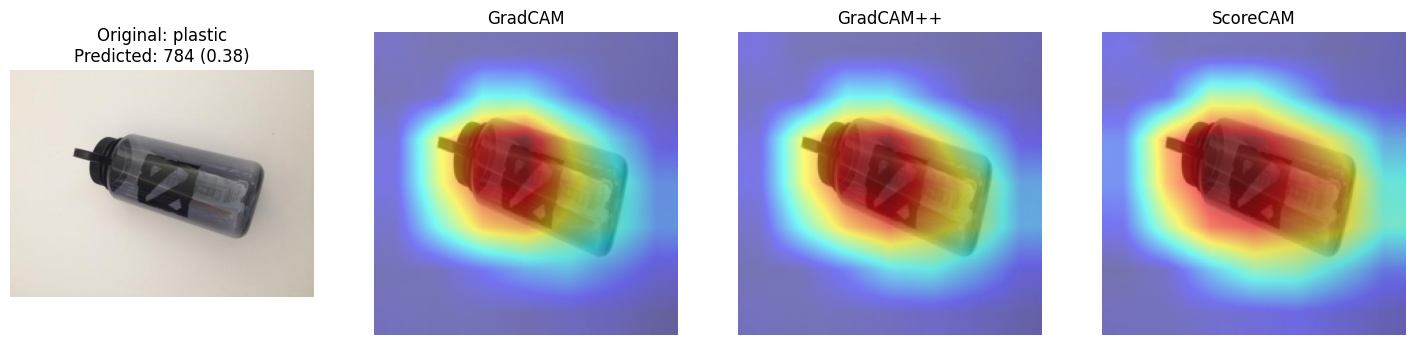

GradCAM vs GradCAM++ overlap: 0.26



In [16]:
for label, path in sample_images.items():
    img = load_image_local(path)
    if img is not None:
        apply_cams(img, label, true_class_index=None)